# Air Quality Monitoring Dashboard - Model Training & Comparison

This notebook demonstrates:
1. Data loading and exploration
2. Data preprocessing and feature engineering
3. Training multiple ML models
4. Model comparison and evaluation
5. Visualization of results
6. Model saving for deployment

In [ ]:
!python3 -m pip install lightgbm
!{sys.executable} -m pip install lightgbm

259.47s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached lightgbm-4.6.0-py3-none-macosx_12_0_arm64.whl (1.6 MB)

[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


265.99s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


zsh:1: parse error near `-m'


In [13]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Model persistence
import joblib
import pickle

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Data Loading and Exploration

In [14]:
# Load the dataset
df = pd.read_csv('globalAirQuality.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (18000, 15)

First 5 rows:


,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


In [15]:
# Data information
print("Data Types and Missing Values:")
df.info()

print("\n" + "="*50)
print("Statistical Summary:")
df.describe()

Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    18000 non-null  object 
 1   country      18000 non-null  object 
 2   city         18000 non-null  object 
 3   latitude     18000 non-null  float64
 4   longitude    18000 non-null  float64
 5   pm25         18000 non-null  float64
 6   pm10         18000 non-null  float64
 7   no2          18000 non-null  float64
 8   so2          18000 non-null  float64
 9   o3           18000 non-null  float64
 10  co           18000 non-null  float64
 11  aqi          18000 non-null  int64  
 12  temperature  18000 non-null  float64
 13  humidity     18000 non-null  float64
 14  wind_speed   18000 non-null  float64
dtypes: float64(11), int64(1), object(3)
memory usage: 2.1+ MB

Statistical Summary:


,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000
mean,23.065980,37.655560,40.369131,70.152228,32.055176,6.035508,48.065100,0.800595,104.645556,21.510251,57.714351,5.283910
std,26.156536,78.600701,17.647450,24.999440,13.820680,2.454790,14.950849,0.250254,25.616070,9.509444,18.844908,2.741712
min,-37.814000,-123.121000,0.025000,0.061000,0.013000,0.003000,0.114000,0.000000,16.000000,5.000000,25.002000,0.500000
25%,12.972000,2.352000,27.904500,53.125500,22.362500,4.360750,38.028500,0.633000,87.000000,13.357750,41.320000,2.937000
50%,29.232000,42.146000,40.286500,69.961000,32.019500,6.026000,48.142000,0.800500,103.000000,21.455500,57.847000,5.297000
75%,41.008000,103.820000,52.436250,87.256500,41.364250,7.715250,58.258500,0.969000,121.000000,29.688250,74.234750,7.662000
max,60.170000,174.763000,115.683000,161.810000,90.019000,16.559000,103.016000,1.832000,231.000000,37.998000,89.997000,9.999000


In [16]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Check for duplicates
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:
Series([], dtype: int64)

Duplicate Rows: 0


## 2. Exploratory Data Analysis (EDA)

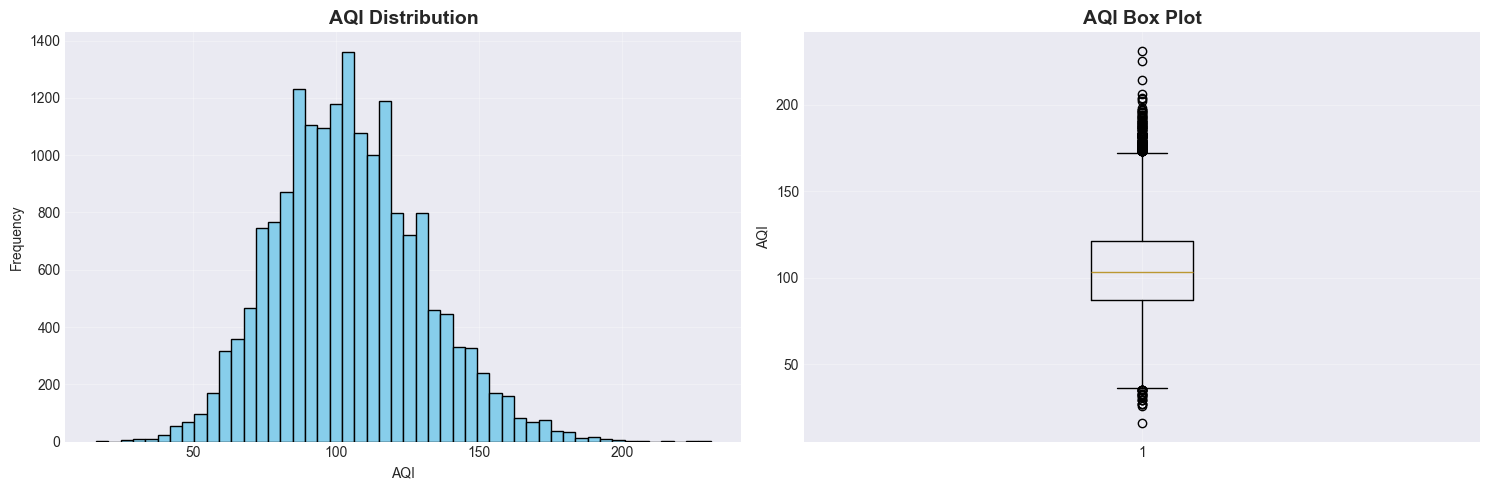

AQI Mean: 104.65
AQI Median: 103.00
AQI Std: 25.62


In [17]:
# Visualize AQI distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['aqi'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('AQI Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['aqi'], vert=True)
axes[1].set_title('AQI Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('AQI')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"AQI Mean: {df['aqi'].mean():.2f}")
print(f"AQI Median: {df['aqi'].median():.2f}")
print(f"AQI Std: {df['aqi'].std():.2f}")

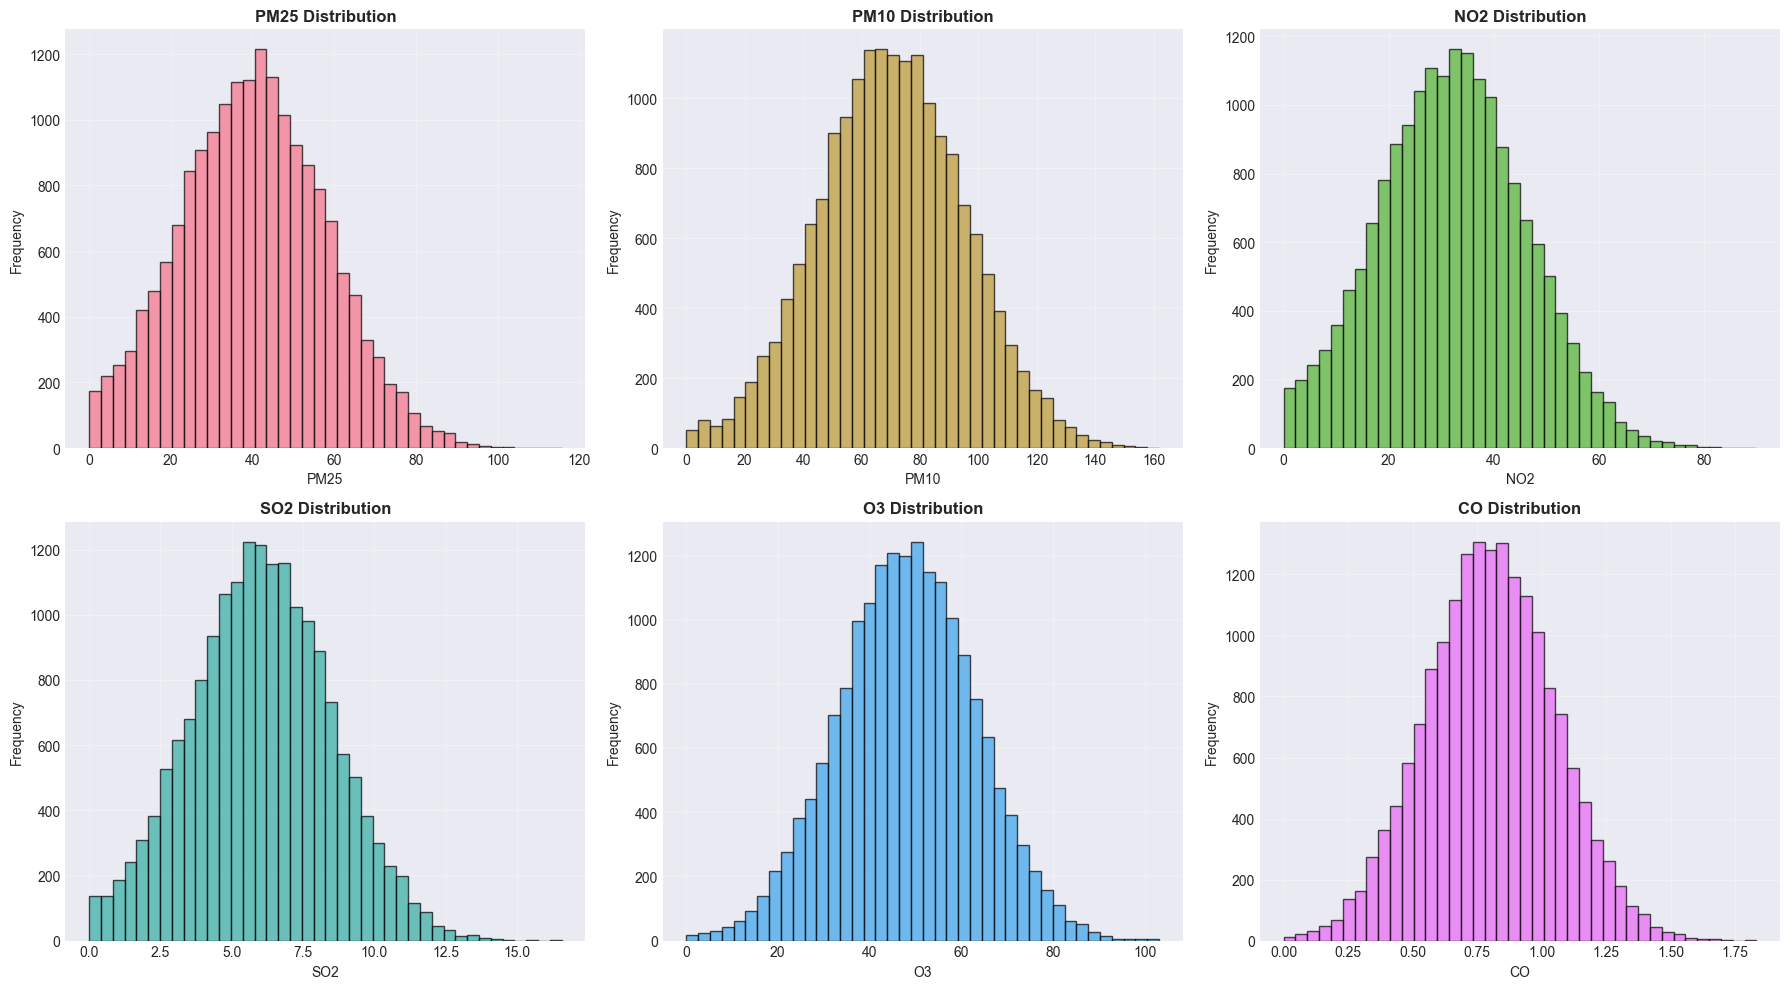

In [18]:
# Visualize pollutant distributions
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'o3', 'co']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, pollutant in enumerate(pollutants):
    axes[idx].hist(df[pollutant], bins=40, color=sns.color_palette('husl')[idx], edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{pollutant.upper()} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(pollutant.upper())
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

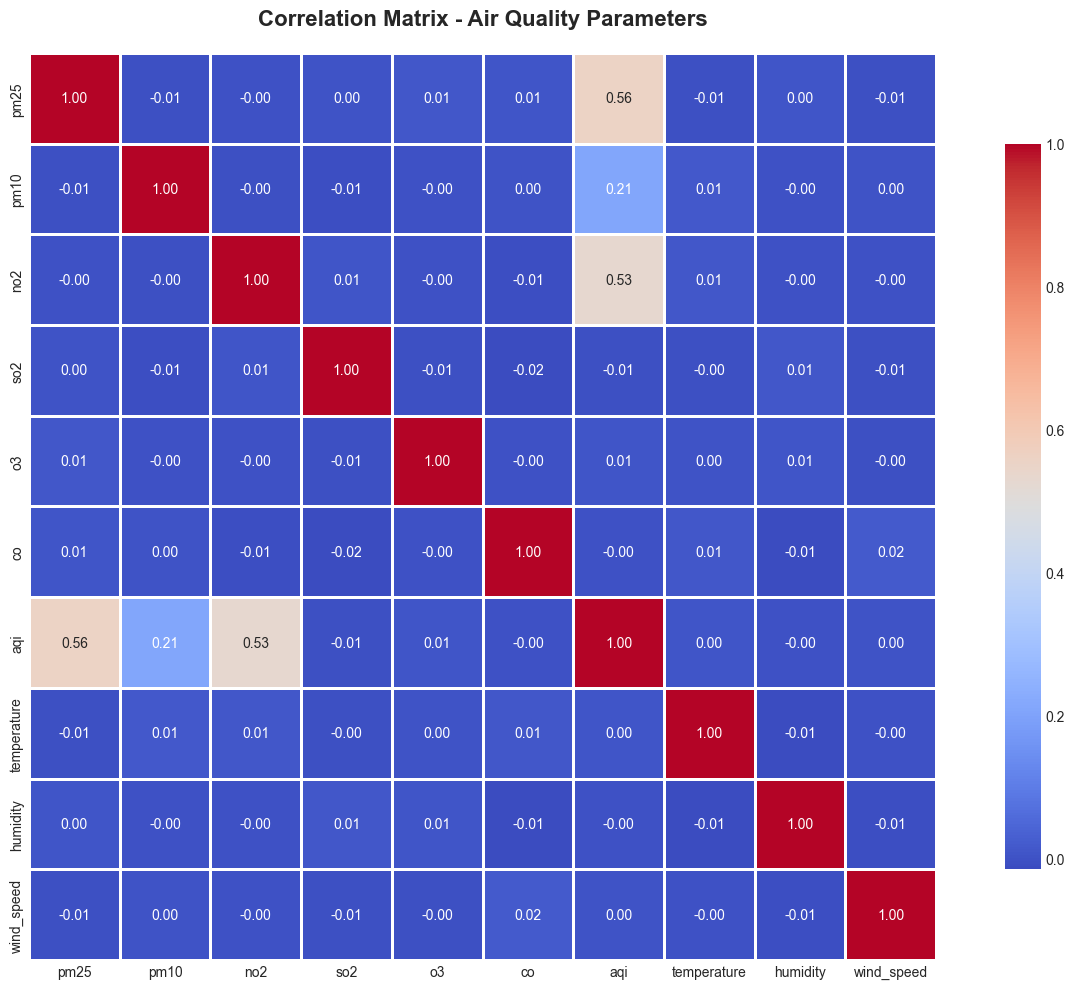


Correlation with AQI (sorted):
aqi            1.000000
pm25           0.556094
no2            0.531731
pm10           0.207499
o3             0.008000
temperature    0.004978
wind_speed     0.003798
humidity      -0.000610
co            -0.001763
so2           -0.005202
Name: aqi, dtype: float64


In [19]:
# Correlation heatmap
plt.figure(figsize=(14, 10))

# Select numeric columns
numeric_cols = ['pm25', 'pm10', 'no2', 'so2', 'o3', 'co', 'aqi', 'temperature', 'humidity', 'wind_speed']
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Air Quality Parameters', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Show strongest correlations with AQI
print("\nCorrelation with AQI (sorted):")
print(correlation_matrix['aqi'].sort_values(ascending=False))

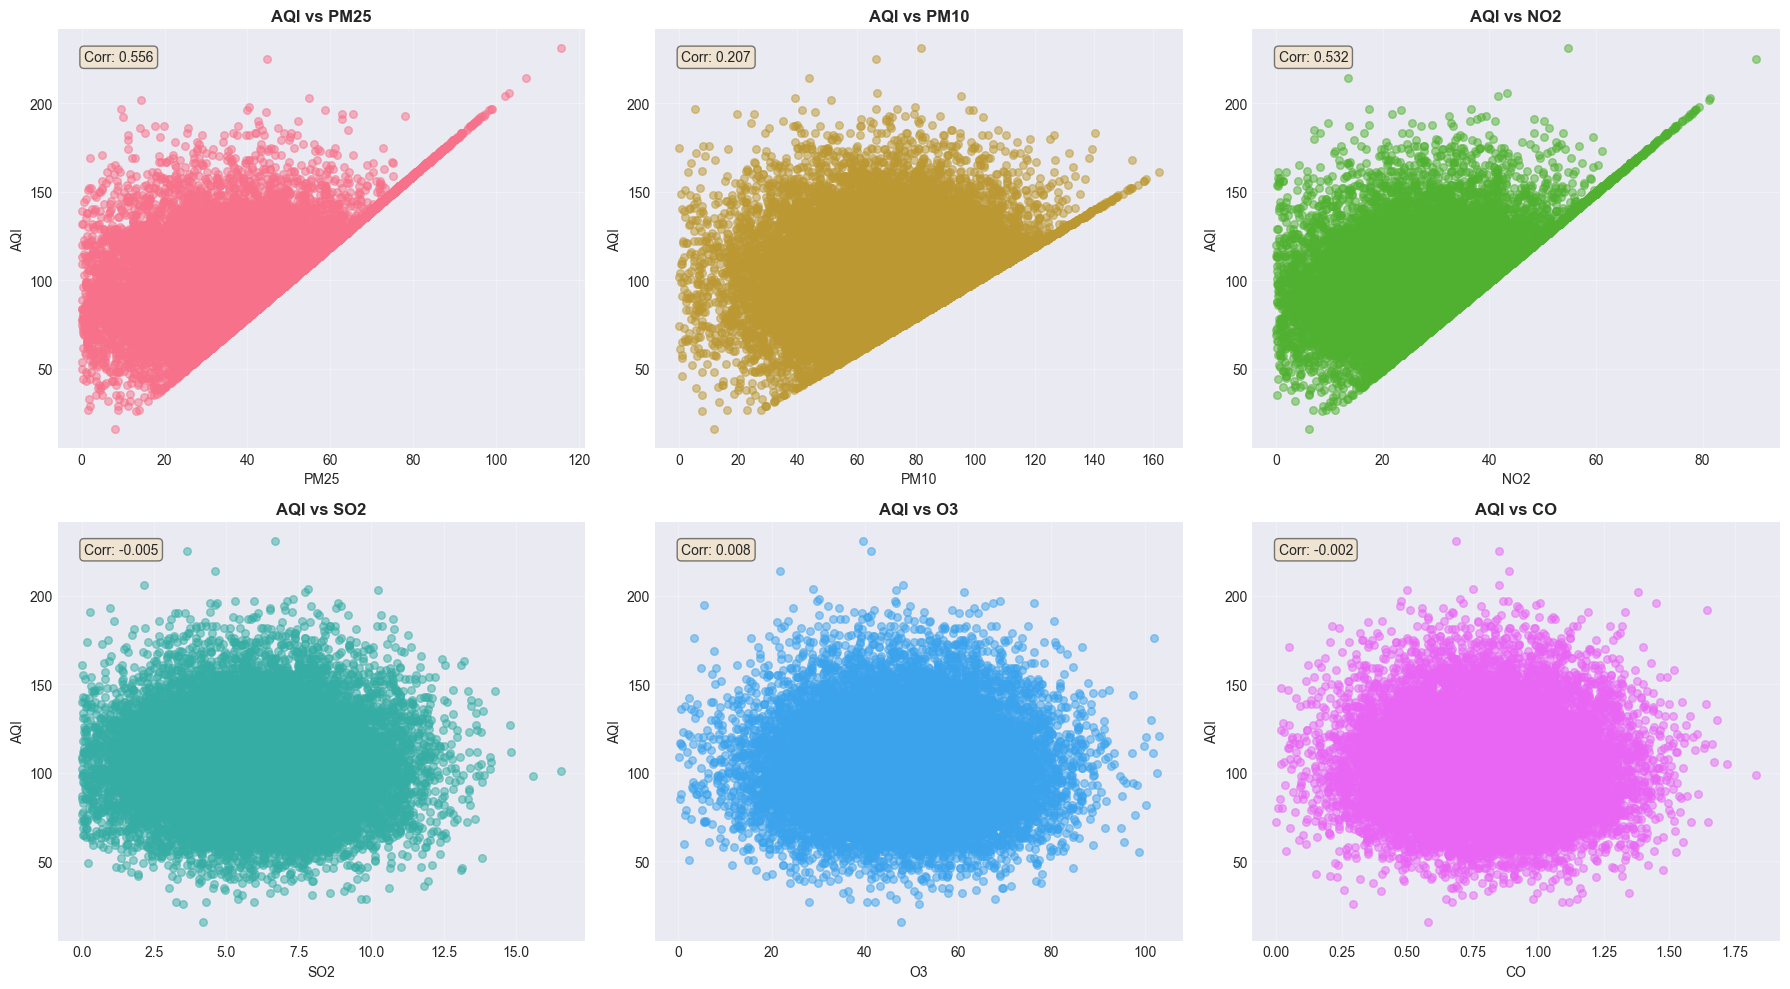

In [20]:
# Scatter plots - Pollutants vs AQI
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, pollutant in enumerate(pollutants):
    axes[idx].scatter(df[pollutant], df['aqi'], alpha=0.5, s=30, color=sns.color_palette('husl')[idx])
    axes[idx].set_title(f'AQI vs {pollutant.upper()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(pollutant.upper())
    axes[idx].set_ylabel('AQI')
    axes[idx].grid(True, alpha=0.3)
    
    # Add correlation coefficient
    corr = df[pollutant].corr(df['aqi'])
    axes[idx].text(0.05, 0.95, f'Corr: {corr:.3f}', 
                   transform=axes[idx].transAxes, 
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Feature Engineering

In [21]:
# Create a copy for preprocessing
df_processed = df.copy()

# Convert timestamp to datetime
df_processed['timestamp'] = pd.to_datetime(df_processed['timestamp'])

# Extract time features
df_processed['hour'] = df_processed['timestamp'].dt.hour
df_processed['day'] = df_processed['timestamp'].dt.day
df_processed['month'] = df_processed['timestamp'].dt.month
df_processed['day_of_week'] = df_processed['timestamp'].dt.dayofweek
df_processed['is_weekend'] = (df_processed['day_of_week'] >= 5).astype(int)

# Encode categorical variables
le_country = LabelEncoder()
le_city = LabelEncoder()

df_processed['country_encoded'] = le_country.fit_transform(df_processed['country'])
df_processed['city_encoded'] = le_city.fit_transform(df_processed['city'])

# Create interaction features
df_processed['pm_ratio'] = df_processed['pm25'] / (df_processed['pm10'] + 1)
df_processed['total_pollutants'] = df_processed['pm25'] + df_processed['pm10'] + df_processed['no2'] + df_processed['so2'] + df_processed['o3'] + df_processed['co']
df_processed['temp_humidity_interaction'] = df_processed['temperature'] * df_processed['humidity']

print("New features created successfully!")
print(f"Total features: {df_processed.shape[1]}")
df_processed.head()

New features created successfully!
Total features: 25


,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,...,hour,day,month,day_of_week,is_weekend,country_encoded,city_encoded,pm_ratio,total_pollutants,temp_humidity_interaction
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,...,18,4,11,1,0,35,32,0.457485,247.434,1298.388672
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,...,19,4,11,1,0,35,32,0.500960,179.878,467.553744
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,...,20,4,11,1,0,35,32,0.505667,185.573,1998.571239
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,...,21,4,11,1,0,35,32,0.375573,213.098,2063.000420
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,...,22,4,11,1,0,35,32,0.312697,180.122,1042.834368


In [22]:
# Define features and target
feature_columns = ['pm25', 'pm10', 'no2', 'so2', 'o3', 'co', 
                   'temperature', 'humidity', 'wind_speed',
                   'latitude', 'longitude',
                   'hour', 'day', 'month', 'day_of_week', 'is_weekend',
                   'country_encoded', 'city_encoded',
                   'pm_ratio', 'total_pollutants', 'temp_humidity_interaction']

X = df_processed[feature_columns]
y = df_processed['aqi']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Check for any missing values
print(f"\nMissing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y.isnull().sum()}")

Features shape: (18000, 21)
Target shape: (18000,)

Missing values in features: 0
Missing values in target: 0


In [23]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nData scaling completed!")

Training set size: 14400
Test set size: 3600

Data scaling completed!


## 4. Model Training & Comparison

In [24]:
# Define models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42),
    'KNN': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'SVR': SVR(kernel='rbf')
}

print(f"Total models to train: {len(models)}")

Total models to train: 11


In [25]:
# Train and evaluate all models
results = []

print("Training models...\n")
print("="*80)

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    
    # Use scaled data for models that benefit from it
    if name in ['Ridge Regression', 'Lasso Regression', 'KNN', 'SVR']:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test
    
    # Train the model
    model.fit(X_train_use, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train_use)
    y_pred_test = model.predict(X_test_use)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    
    # Cross-validation score
    cv_scores = cross_val_score(model, X_train_use, y_train, cv=5, 
                                scoring='r2', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    results.append({
        'Model': name,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'CV_R2_Mean': cv_mean,
        'CV_R2_Std': cv_std
    })
    
    print(f"✓ Test R²: {test_r2:.4f}")

print("="*80)
print("\nAll models trained successfully!")

353.94s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/Users/codeaj/Library/Python/3.10/lib/python/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
  File "/Users/codeaj/Library/Python/3.10/lib/python/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
TypeError: a bytes-like object is required, not 'str'


Training models...

Training Linear Regression... 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

✓ Test R²: 0.6274
Training Ridge Regression... 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

✓ Test R²: 0.6274
Training Lasso Regression... 

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


✓ Test R²: 0.6263
Training Decision Tree... ✓ Test R²: 0.9917
Training Random Forest... ✓ Test R²: 0.9994
Training Gradient Boosting... ✓ Test R²: 0.9925
Training XGBoost... ✓ Test R²: 0.9970
Training LightGBM... ✓ Test R²: 0.9973
Training AdaBoost... ✓ Test R²: 0.8653
Training KNN... ✓ Test R²: 0.6733
Training SVR... ✓ Test R²: 0.8780

All models trained successfully!


In [26]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test_R2', ascending=False).reset_index(drop=True)

print("Model Comparison Results:")
print("="*100)
results_df

Model Comparison Results:


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,CV_R2_Mean,CV_R2_Std
0,Random Forest,0.240579,0.601151,0.046485,0.103639,0.999914,0.999391,0.999116,0.000509
1,LightGBM,0.847083,1.269623,0.504046,0.556297,0.998932,0.997282,0.997429,0.000586
2,XGBoost,0.557174,1.342217,0.420720,0.725347,0.999538,0.996962,0.996921,0.000460
3,Gradient Boosting,2.120354,2.108817,1.459530,1.464974,0.993309,0.992501,0.990877,0.000891
4,Decision Tree,2.195618,2.225110,0.865582,0.886255,0.992825,0.991651,0.991802,0.001472
5,SVR,8.565780,8.506525,6.476926,6.557710,0.890799,0.877976,0.864020,0.004689
6,AdaBoost,9.072144,8.937456,7.257531,7.151899,0.877506,0.865299,0.869320,0.010172
7,KNN,11.819585,13.919656,9.138542,10.819444,0.792079,0.673263,0.672875,0.004537
8,Ridge Regression,15.427611,14.863537,12.320998,11.931670,0.645765,0.627449,0.643720,0.009090
9,Linear Regression,15.427611,14.863604,12.321016,11.931748,0.645765,0.627446,0.643720,0.009091


## 5. Model Performance Visualization

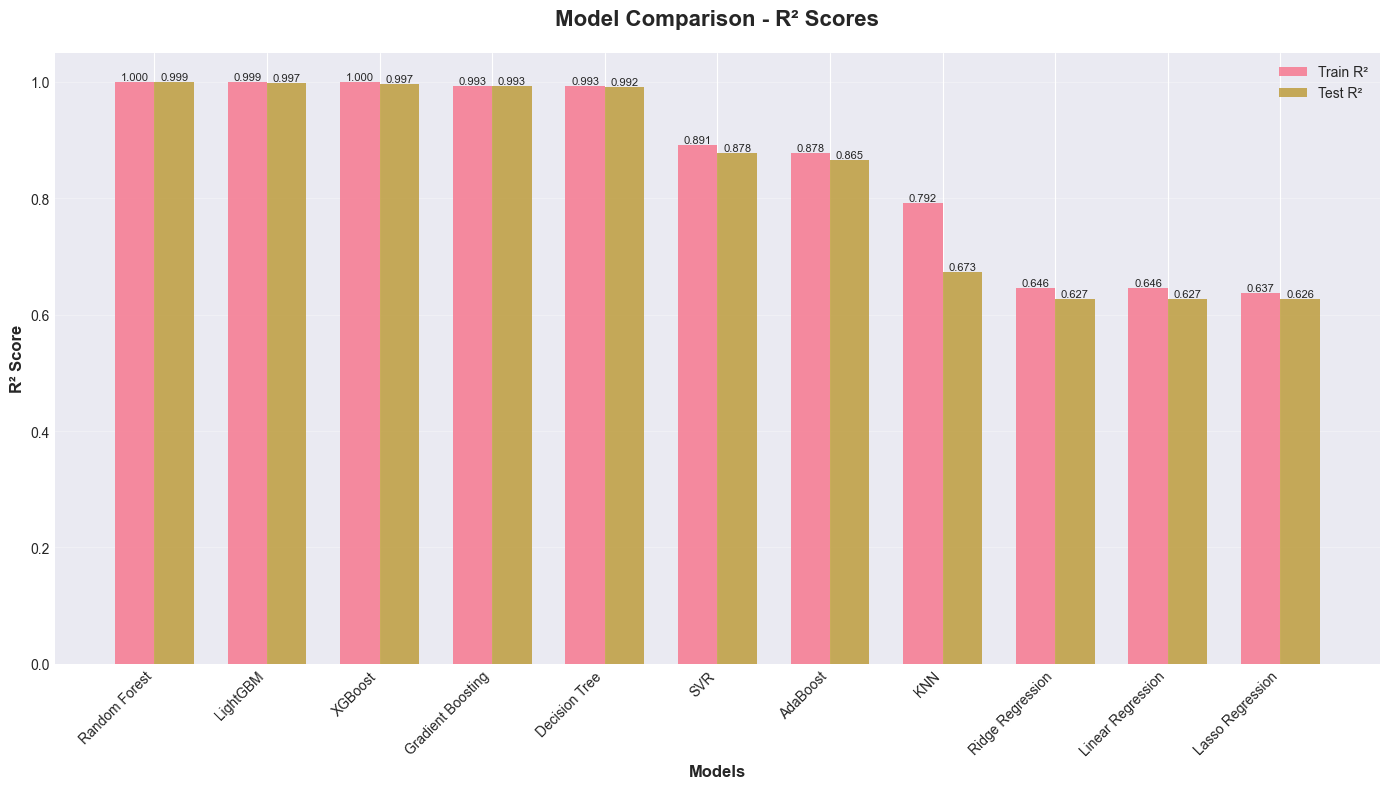

In [27]:
# Compare R² scores
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Train_R2'], width, label='Train R²', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df['Test_R2'], width, label='Test R²', alpha=0.8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - R² Scores', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

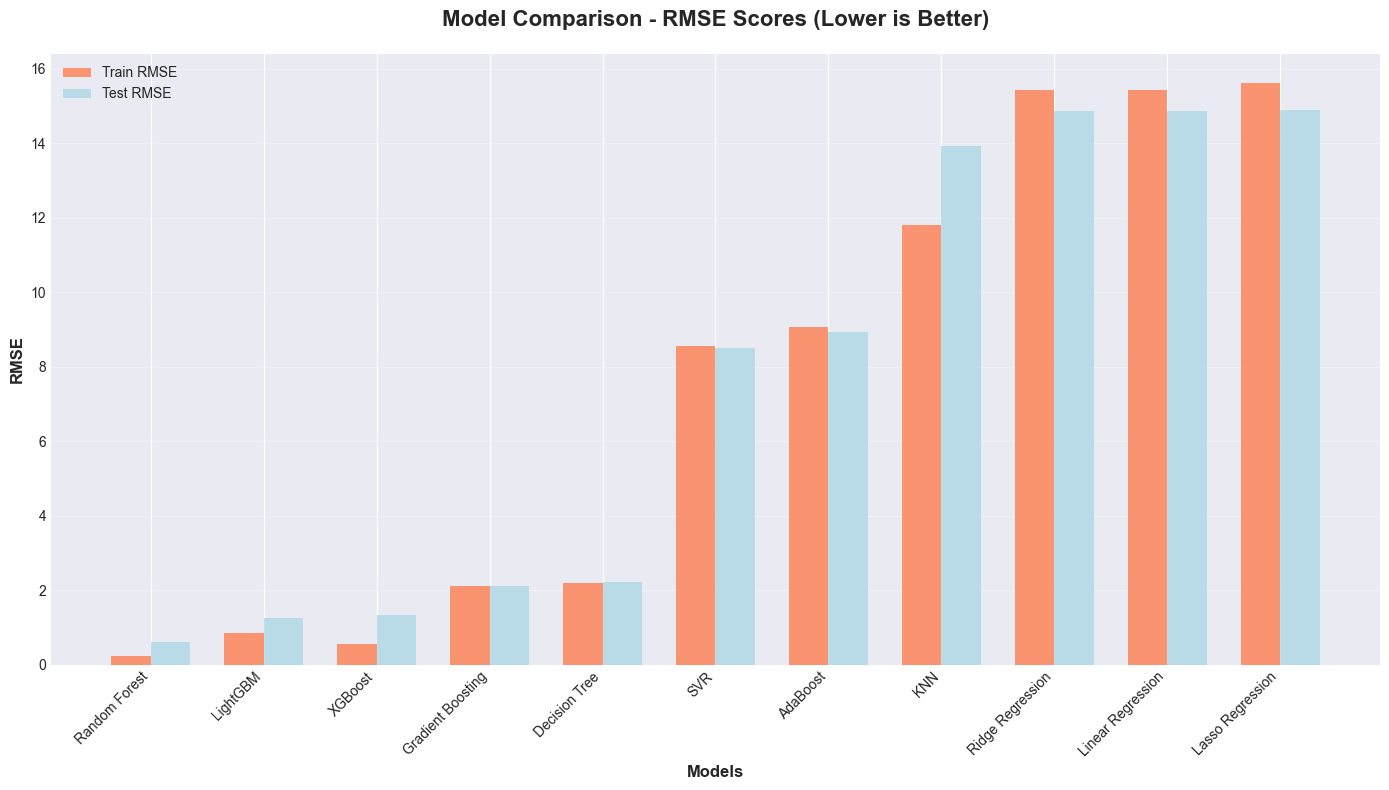

In [28]:
# Compare RMSE scores
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Train_RMSE'], width, label='Train RMSE', alpha=0.8, color='coral')
bars2 = ax.bar(x + width/2, results_df['Test_RMSE'], width, label='Test RMSE', alpha=0.8, color='lightblue')

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - RMSE Scores (Lower is Better)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

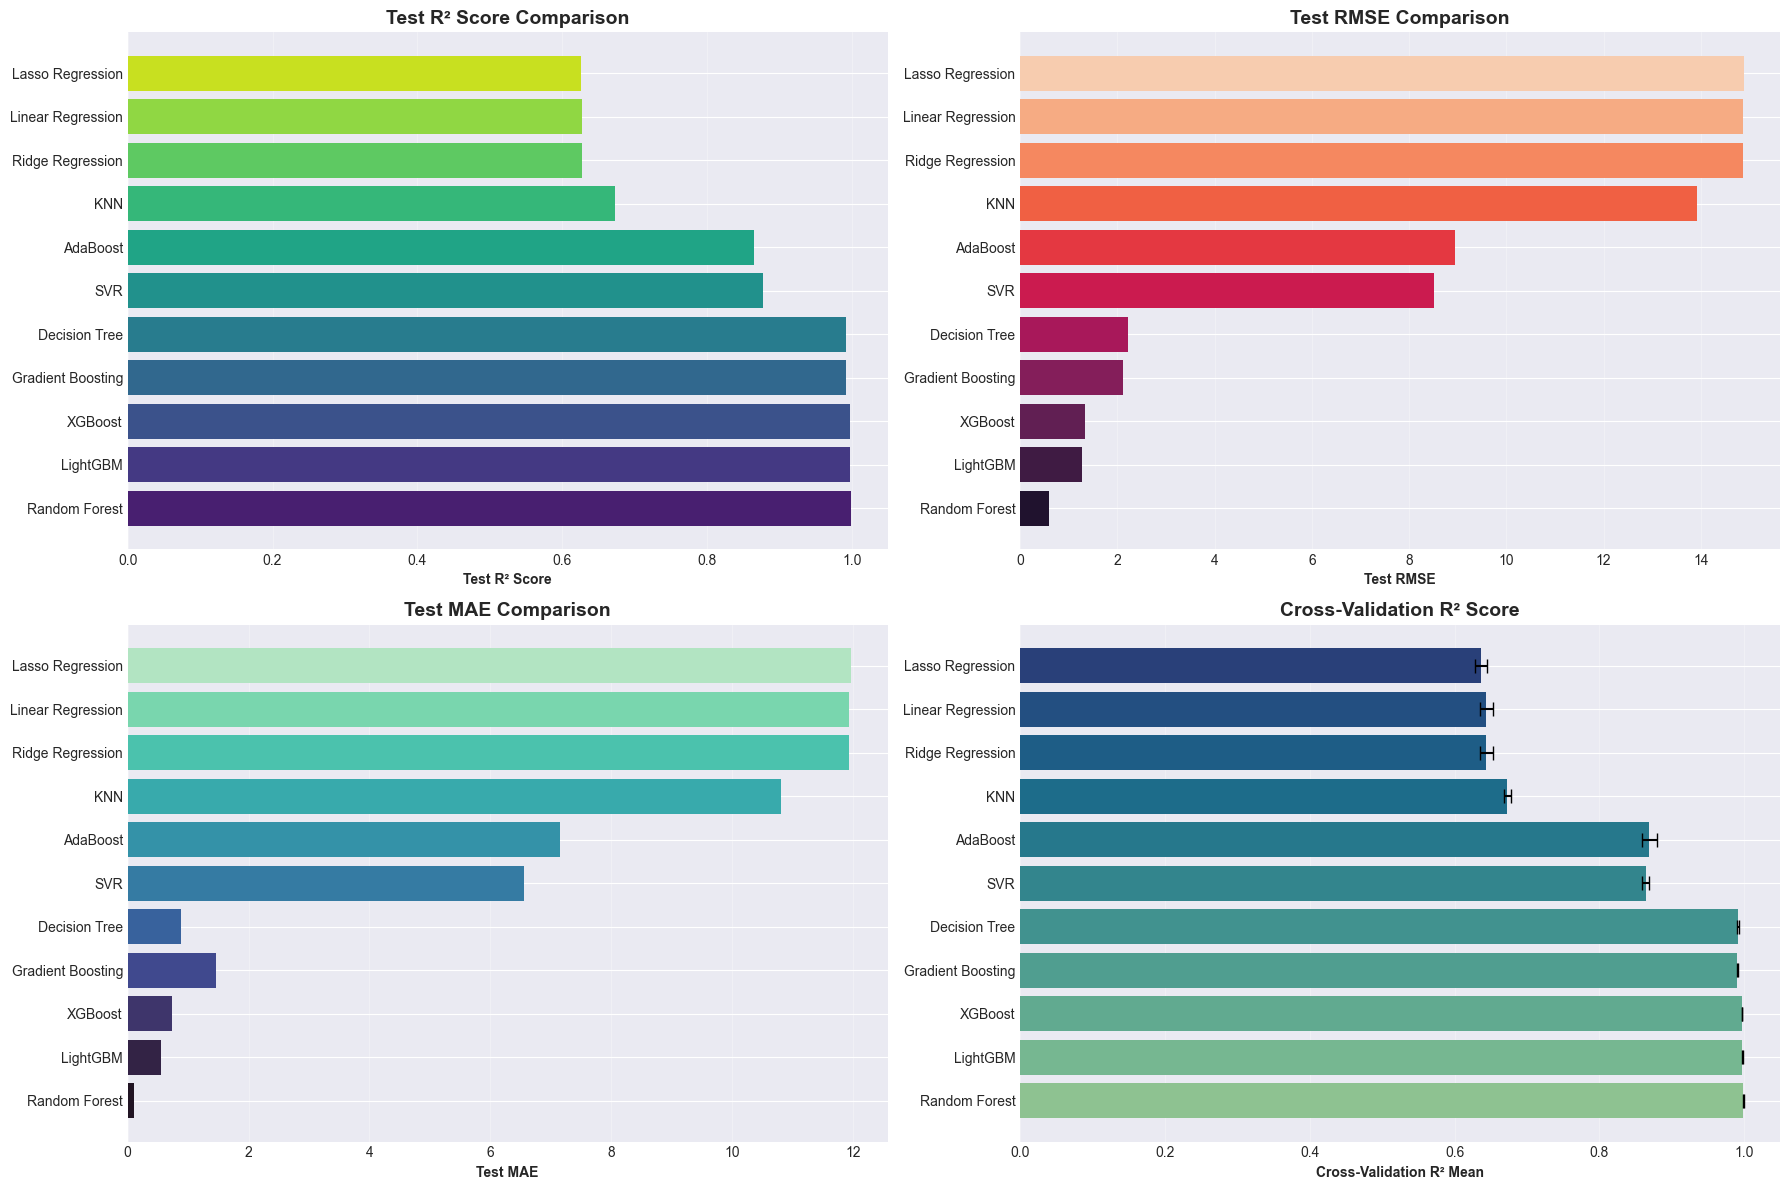

In [29]:
# Create a comprehensive comparison plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Test R² Score
axes[0, 0].barh(results_df['Model'], results_df['Test_R2'], color=sns.color_palette('viridis', len(results_df)))
axes[0, 0].set_xlabel('Test R² Score', fontweight='bold')
axes[0, 0].set_title('Test R² Score Comparison', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# Test RMSE
axes[0, 1].barh(results_df['Model'], results_df['Test_RMSE'], color=sns.color_palette('rocket', len(results_df)))
axes[0, 1].set_xlabel('Test RMSE', fontweight='bold')
axes[0, 1].set_title('Test RMSE Comparison', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# Test MAE
axes[1, 0].barh(results_df['Model'], results_df['Test_MAE'], color=sns.color_palette('mako', len(results_df)))
axes[1, 0].set_xlabel('Test MAE', fontweight='bold')
axes[1, 0].set_title('Test MAE Comparison', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Cross-validation R² with error bars
axes[1, 1].barh(results_df['Model'], results_df['CV_R2_Mean'], 
                xerr=results_df['CV_R2_Std'], 
                color=sns.color_palette('crest', len(results_df)),
                capsize=5)
axes[1, 1].set_xlabel('Cross-Validation R² Mean', fontweight='bold')
axes[1, 1].set_title('Cross-Validation R² Score', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 6. Best Model Analysis

In [30]:
# Select the best model based on Test R²
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

print(f"Best Model: {best_model_name}")
print("="*80)
print(f"Test R² Score: {results_df.iloc[0]['Test_R2']:.4f}")
print(f"Test RMSE: {results_df.iloc[0]['Test_RMSE']:.4f}")
print(f"Test MAE: {results_df.iloc[0]['Test_MAE']:.4f}")
print(f"Cross-Validation R² Mean: {results_df.iloc[0]['CV_R2_Mean']:.4f} ± {results_df.iloc[0]['CV_R2_Std']:.4f}")

Best Model: Random Forest
Test R² Score: 0.9994
Test RMSE: 0.6012
Test MAE: 0.1036
Cross-Validation R² Mean: 0.9991 ± 0.0005


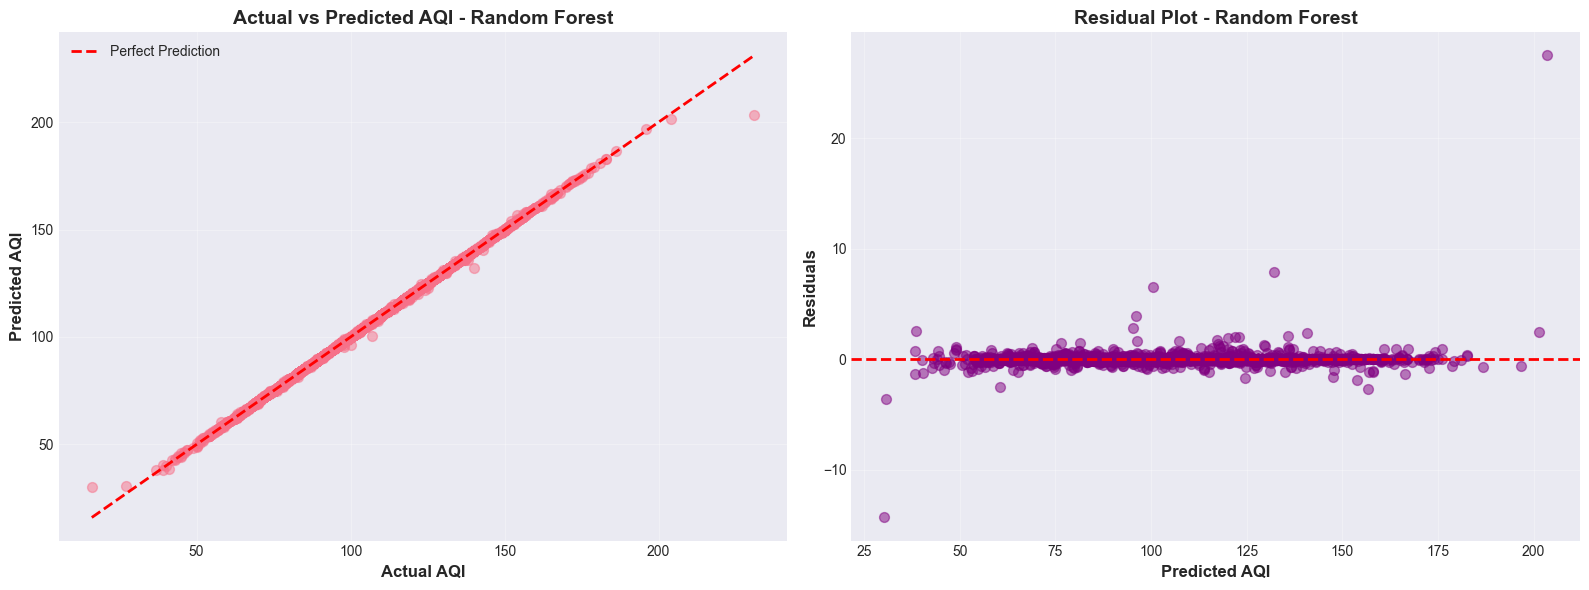

In [31]:
# Get predictions from best model
if best_model_name in ['Ridge Regression', 'Lasso Regression', 'KNN', 'SVR']:
    X_test_use = X_test_scaled
else:
    X_test_use = X_test

y_pred_best = best_model.predict(X_test_use)

# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=50)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual AQI', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted AQI', fontsize=12, fontweight='bold')
axes[0].set_title(f'Actual vs Predicted AQI - {best_model_name}', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=50, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted AQI', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[1].set_title(f'Residual Plot - {best_model_name}', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

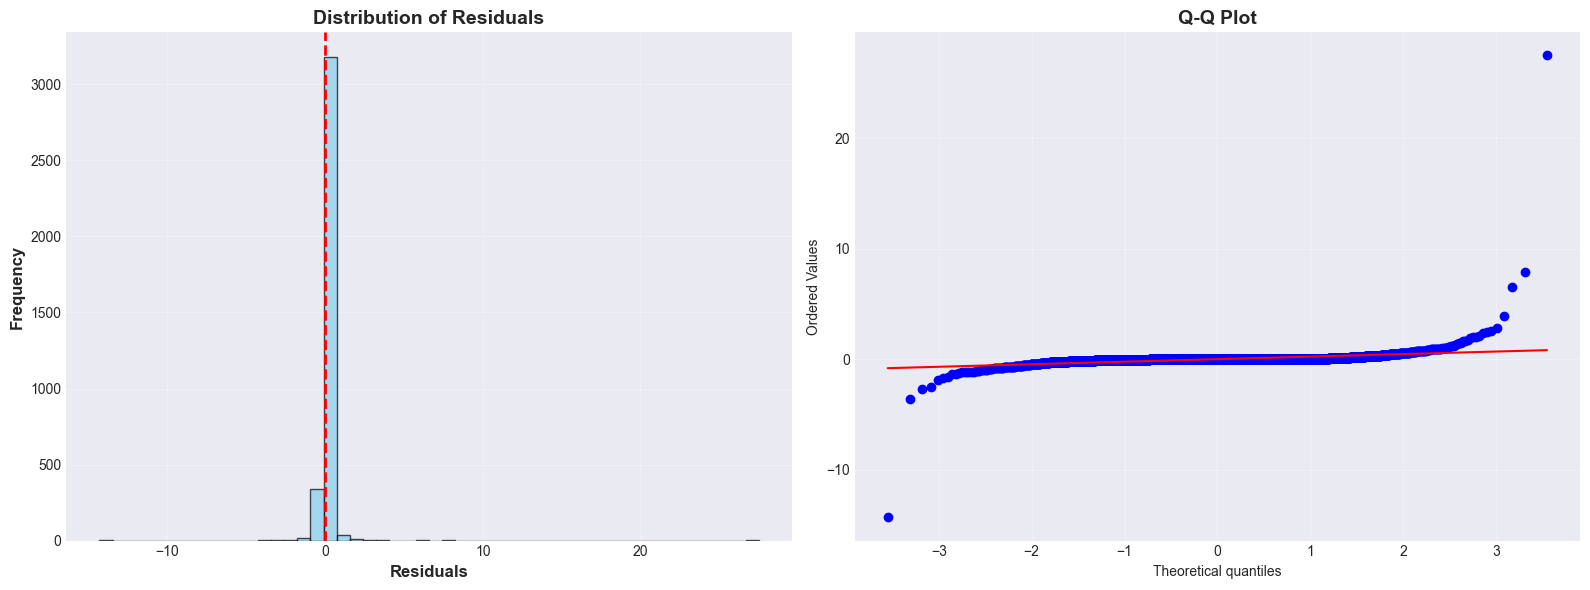

Residuals Mean: 0.0135
Residuals Std: 0.6011


In [32]:
# Distribution of residuals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Residuals', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title('Distribution of Residuals', fontsize=14, fontweight='bold')
axes[0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[0].grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Residuals Mean: {residuals.mean():.4f}")
print(f"Residuals Std: {residuals.std():.4f}")

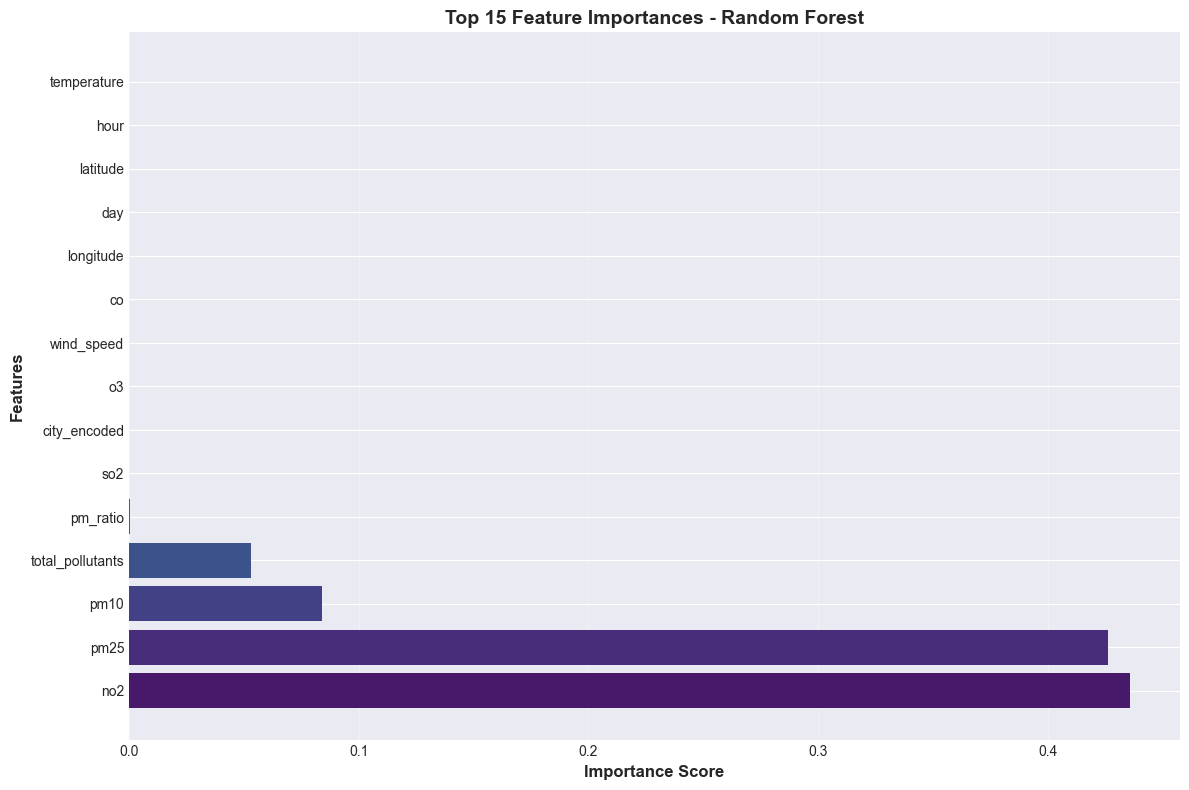


Top 10 Most Important Features:
             Feature  Importance
2                no2    0.435876
0               pm25    0.426300
1               pm10    0.084199
19  total_pollutants    0.053026
18          pm_ratio    0.000231
3                so2    0.000047
17      city_encoded    0.000044
4                 o3    0.000043
8         wind_speed    0.000037
5                 co    0.000029


In [33]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15], 
             color=sns.color_palette('viridis', 15))
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Feature Importances - {best_model_name}', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))
else:
    print(f"\n{best_model_name} does not provide feature importance scores.")

## 7. Hyperparameter Tuning (Optional - Best Model)

In [34]:
# Hyperparameter tuning for the best model
print(f"Performing hyperparameter tuning for {best_model_name}...\n")

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    tuned_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 10],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0]
    }
    tuned_model = XGBRegressor(random_state=42, n_jobs=-1)
    
elif best_model_name == 'LightGBM':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15, -1],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 50, 100]
    }
    tuned_model = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.8, 0.9, 1.0]
    }
    tuned_model = GradientBoostingRegressor(random_state=42)
else:
    print(f"Skipping hyperparameter tuning for {best_model_name}")
    param_grid = None

if param_grid:
    # Use scaled or unscaled data based on model
    if best_model_name in ['Ridge Regression', 'Lasso Regression', 'KNN', 'SVR']:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
    else:
        X_train_use = X_train
        X_test_use = X_test
    
    # Grid search with reduced parameter space for speed
    grid_search = GridSearchCV(
        tuned_model, 
        param_grid, 
        cv=3, 
        scoring='r2', 
        n_jobs=-1, 
        verbose=1
    )
    
    grid_search.fit(X_train_use, y_train)
    
    print(f"\nBest Parameters: {grid_search.best_params_}")
    print(f"Best Cross-Validation R² Score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model on test set
    y_pred_tuned = grid_search.predict(X_test_use)
    tuned_r2 = r2_score(y_test, y_pred_tuned)
    tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
    
    print(f"\nTuned Model Performance:")
    print(f"Test R² Score: {tuned_r2:.4f}")
    print(f"Test RMSE: {tuned_rmse:.4f}")
    print(f"Test MAE: {tuned_mae:.4f}")
    
    # Update best model if tuned is better
    if tuned_r2 > results_df.iloc[0]['Test_R2']:
        best_model = grid_search.best_estimator_
        print("\n✓ Tuned model performs better! Using tuned model.")
    else:
        print("\n✗ Original model performs better. Keeping original model.")

Performing hyperparameter tuning for Random Forest...

Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation R² Score: 0.9991

Tuned Model Performance:
Test R² Score: 0.9994
Test RMSE: 0.5912
Test MAE: 0.1026

✓ Tuned model performs better! Using tuned model.


## 8. Model Saving

In [35]:
# Save the best model
model_filename = f'aqi_model_{best_model_name.replace(" ", "_").lower()}.pkl'
scaler_filename = 'aqi_scaler.pkl'
encoders_filename = 'aqi_encoders.pkl'

# Save model
joblib.dump(best_model, model_filename)
print(f"✓ Model saved as: {model_filename}")

# Save scaler
joblib.dump(scaler, scaler_filename)
print(f"✓ Scaler saved as: {scaler_filename}")

# Save encoders
encoders = {
    'country_encoder': le_country,
    'city_encoder': le_city,
    'feature_columns': feature_columns
}
joblib.dump(encoders, encoders_filename)
print(f"✓ Encoders saved as: {encoders_filename}")

# Save results
results_df.to_csv('model_comparison_results.csv', index=False)
print(f"✓ Results saved as: model_comparison_results.csv")

✓ Model saved as: aqi_model_random_forest.pkl
✓ Scaler saved as: aqi_scaler.pkl
✓ Encoders saved as: aqi_encoders.pkl
✓ Results saved as: model_comparison_results.csv


## 9. Testing the Saved Model

In [36]:
# Load the saved model
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
loaded_encoders = joblib.load(encoders_filename)

print("✓ Model loaded successfully!")
print(f"Model type: {type(loaded_model).__name__}")

✓ Model loaded successfully!
Model type: RandomForestRegressor


In [37]:
# Test prediction with a sample
sample_data = X_test.iloc[0:5]
print("Sample Input Data:")
print(sample_data)
print("\nActual AQI:")
print(y_test.iloc[0:5].values)

# Make predictions
if best_model_name in ['Ridge Regression', 'Lasso Regression', 'KNN', 'SVR']:
    sample_scaled = loaded_scaler.transform(sample_data)
    predictions = loaded_model.predict(sample_scaled)
else:
    predictions = loaded_model.predict(sample_data)

print("\nPredicted AQI:")
print(predictions)
print("\nPrediction Differences:")
print(y_test.iloc[0:5].values - predictions)

Sample Input Data:
        pm25     pm10     no2    so2      o3     co  temperature  humidity  \
2574  38.703  119.930  15.106  3.703  45.711  0.528       22.555    40.499   
7496  40.611   64.421  28.705  5.983  37.538  0.863       32.378    51.200   
9210  26.769   50.826  28.861  6.197  23.735  1.094        6.027    73.056   
5456  45.219   78.348  32.937  4.411  39.308  0.501       12.439    71.855   
736   65.367   96.361  38.867  2.375  45.715  0.689       29.586    86.456   

      wind_speed  latitude  ...  hour  day  month  day_of_week  is_weekend  \
2574       9.384    43.653  ...     0    7     11            4           0   
7496       7.237    12.972  ...     2   17     11            0           0   
9210       8.389    37.566  ...    12   13     11            3           0   
5456       4.464    25.205  ...     2    7     11            4           0   
736        2.991    51.507  ...    10    5     11            2           0   

      country_encoded  city_encoded  pm_rat

## 10. Summary Report

In [38]:
print("="*100)
print("AIR QUALITY MONITORING DASHBOARD - MODEL TRAINING SUMMARY")
print("="*100)
print(f"\nDataset Information:")
print(f"  - Total Samples: {len(df)}")
print(f"  - Training Samples: {len(X_train)}")
print(f"  - Test Samples: {len(X_test)}")
print(f"  - Features Used: {len(feature_columns)}")

print(f"\nModels Evaluated: {len(models)}")
print(f"\nBest Model: {best_model_name}")
print(f"  - Test R² Score: {results_df.iloc[0]['Test_R2']:.4f}")
print(f"  - Test RMSE: {results_df.iloc[0]['Test_RMSE']:.4f}")
print(f"  - Test MAE: {results_df.iloc[0]['Test_MAE']:.4f}")
print(f"  - CV R² Mean: {results_df.iloc[0]['CV_R2_Mean']:.4f}")

print(f"\nTop 3 Models:")
for i in range(min(3, len(results_df))):
    print(f"  {i+1}. {results_df.iloc[i]['Model']}: R² = {results_df.iloc[i]['Test_R2']:.4f}")

print(f"\nSaved Files:")
print(f"  - {model_filename}")
print(f"  - {scaler_filename}")
print(f"  - {encoders_filename}")
print(f"  - model_comparison_results.csv")

print("\n" + "="*100)
print("Model training completed successfully! Ready for deployment.")
print("="*100)

AIR QUALITY MONITORING DASHBOARD - MODEL TRAINING SUMMARY

Dataset Information:
  - Total Samples: 18000
  - Training Samples: 14400
  - Test Samples: 3600
  - Features Used: 21

Models Evaluated: 11

Best Model: Random Forest
  - Test R² Score: 0.9994
  - Test RMSE: 0.6012
  - Test MAE: 0.1036
  - CV R² Mean: 0.9991

Top 3 Models:
  1. Random Forest: R² = 0.9994
  2. LightGBM: R² = 0.9973
  3. XGBoost: R² = 0.9970

Saved Files:
  - aqi_model_random_forest.pkl
  - aqi_scaler.pkl
  - aqi_encoders.pkl
  - model_comparison_results.csv

Model training completed successfully! Ready for deployment.
